In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [4]:
df=df.drop(columns=['Cabin','Embarked','Name','Ticket'])

In [5]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22.0,1,0,7.2500
1,2,1,1,female,38.0,1,0,71.2833
2,3,1,3,female,26.0,0,0,7.9250
3,4,1,1,female,35.0,1,0,53.1000
4,5,0,3,male,35.0,0,0,8.0500


In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Sex             object
Age            float64
SibSp            int64
Parch            int64
Fare           float64
dtype: object

In [7]:
df=pd.get_dummies(df,columns=["Sex"])

In [8]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,1,0,3,22.0,1,0,7.2500,False,True
1,2,1,1,38.0,1,0,71.2833,True,False
2,3,1,3,26.0,0,0,7.9250,True,False
3,4,1,1,35.0,1,0,53.1000,True,False
4,5,0,3,35.0,0,0,8.0500,False,True


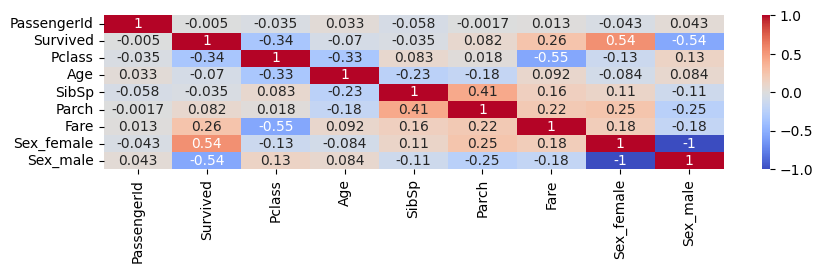

In [9]:
plt.figure(figsize=(10,2))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

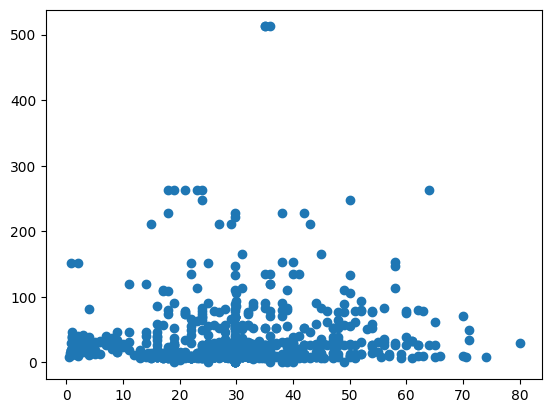

In [10]:
plt.scatter(df['Age'],df['Fare'])
plt.show()

In [11]:
X=df.drop(columns=['Survived'])
y=df['Survived']

X_train, X_test, y_train, y_test =train_test_split(X,y,random_state=42,test_size=0.2)

ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [12]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)
print("Report: ",classification_report(y_test,y_pred))
acc=accuracy_score(y_test,y_pred)
print(acc)

Report:                precision    recall  f1-score   support

           0       0.79      0.88      0.83       105
           1       0.79      0.68      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

0.7932960893854749


In [13]:
gnb=GaussianNB()
gnb.fit(X_train,y_train)

y_pred2=gnb.predict(X_test)
print("Report: ",classification_report(y_test,y_pred2))
acc2=accuracy_score(y_test,y_pred2)
print(acc2)

Report:                precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

0.7877094972067039


In [14]:
knnprobab=knn.predict_proba(X_test)
nbprobab=gnb.predict_proba(X_test)

In [15]:
print(roc_auc_score(y_test,knnprobab[:,-1]))
print(roc_auc_score(y_test,nbprobab[:,-1]))

0.8643500643500643
0.8595881595881596


In [16]:
dt=DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred3=dt.predict(X_test)
print("Report: ",classification_report(y_test,y_pred2))
acc3=accuracy_score(y_test,y_pred2)
print(acc3)

Report:                precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

0.7877094972067039


In [17]:
sv=SVC()
sv.fit(X_train,y_train)
y_pred4=sv.predict(X_test)

print("Report: ",classification_report(y_test,y_pred2))
acc4=accuracy_score(y_test,y_pred2)
print(acc4)

Report:                precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

0.7877094972067039


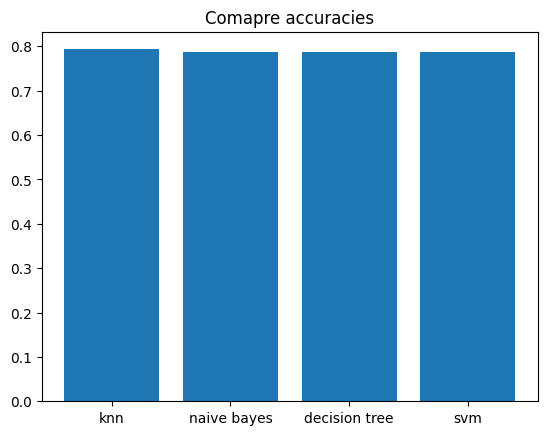

In [18]:
models=['knn','naive bayes','decision tree','svm']
accus=[acc,acc2,acc3,acc4]
plt.title('Comapre accuracies')
plt.bar(models,accus)
plt.show()

In [22]:
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
cvsco=cross_val_score(DecisionTreeClassifier(),X,y,scoring='accuracy')
print(cvsco)

[0.52513966 0.78651685 0.78089888 0.7752809  0.83707865]
